<a href="https://colab.research.google.com/github/javiermagnone-lab/Javito/blob/main/Tarea_2_ML_analisis_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tarea 2 - ML para analisis de datos**

**Integrantes:** Valentina Corrotti - Guzmán Momplet - Javier Magnone (378574)

**Repositorio:** https://github.com/javiermagnone-lab/Javito/blob/main/Tarea_2_ML_analisis_de_datos.ipynb
___________________________________



## **Tareas a realizar:**

|Cuaderno | Tarea |Detalle|
|---|---|---|
|pr_2.ipynb| 2.1| Estudiar las principales características de la variable de respuesta: análisis gráfico de normalidad; opción por la transformación logarítmica. Investigar qué presentan las gráficas qqplot y qué conclusiones podemos extraer acerca de la normalidad de la variable|
|pr_2.ipynb |2.2 | Completar el análisis exploratorio de datos (AED) de variables predictoras, en particular sobre la correlación entre variables predictoras (buscar métodos gráficos para ello) y sus consecuencias en la implementación de regresión|
|pr_2.ipynb |2.3 |Investigar qué es y en qué condiciones conviene realizar la ESTANDARIZACIÓN de variables numéricas en el contexto de regresión para la transformación de variables predictoras numéricas|
|pr_2.ipynb |2.4 |Realizar al menos tres derivaciones del modelo 2 (2.a, 2.b, 2.c) cada una con mayor grado en el polinomio. Analizar los resultados y conclusiones, considerando particularmente la evidencia acerca del problema del sobreajuste. Nota: puede ser seleccionada otra variable para realizar la regresión polinómica, con miras a un mejor desempeño|
|pr_2.ipynb |2.5 |Incorporar más variables. Analizar los resultados y conclusiones, considerando particularmente la evidencia acerca del problema del sobreajuste|
|pr_2_reg_cv.ipynb|2.6 |Analizar los resultados de utilizar validación cruzada, ¿qué conclusiones obtiene?|
|pr_2_reg_cv.ipynb|2.7 |Analizar los resultados al incorporar más variables y aplicar la regularización utilizando Ridge y Lasso, ¿qué conclusiones obtiene? ¿Se cumple la selección de variables alaplicar Lasso?|
|pr_2_reg_cv.ipynb|2.8 |¿Qué conclusiones obtiene? ¿Se cumple la selección de variables al aplicar Lasso? Agregar más variables y comentar los resultados|
|pr_2_reg_cv.ipynb|2.9 |Ídem a 2.8, pero usando Ridge|

# **Cronología del Notebook:**

|# | Sección | Estado|
|---|---|---|
|00| Carga de librerías y dataset| Finalizado|
|01| Preparación de los datos | Finalizado|
|02|Tarea 2.1| Comenzado|
|03|Tarea 2.2| No Comenzado|
|04|Tarea 2.3| No Comenzado|
|05|Tarea 2.4| No Comenzado|
|06|Tarea 2.5| No Comenzado|
|07|Tarea 2.6| No Comenzado|
|08|Tarea 2.7| No Comenzado|
|09|Tarea 2.8| No Comenzado|
|10|Tarea 2.9| No Comenzado|



## **00. Carga de librerías y dataset de trabajo**

In [1]:
pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 35.7 MB/s eta 0:00:00


In [2]:
#Librerías

# setup
import os # Obtener directorios de trabajo
import numpy as np
import pandas as pd
import pyreadstat
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [4]:
!pip install gdown

## **Carga del dataset de trabajo**

*Resumen*
|Tarea| Código | Estado
|---|---|---|
|Carga del dataset|.sav|Listo|
|Importar data|pd_read_spss|Listo|
|Columnas del dataset|.columns.values.tolist()|Listo|
|Primeras 5 filas|.head()|Listo|


In [12]:
#Carga del dataset

file_id = '13zImdLBAT-WZ3F4jAmloc5ul8nQx2y2V'
output_filename = 'Tarea_2_P_2017_Terceros.sav'
!gdown --id $file_id -O $output_filename

# Update the file_path to point to the downloaded file
file_path = f'/content/{output_filename}'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=13zImdLBAT-WZ3F4jAmloc5ul8nQx2y2V
From (redirected): https://drive.google.com/uc?id=13zImdLBAT-WZ3F4jAmloc5ul8nQx2y2V&confirm=t&uuid=6871a33f-e0f5-47fc-98ef-24701ed3b9fb
To: /content/Tarea_2_P_2017_Terceros.sav
100% 115M/115M [00:02<00:00, 56.6MB/s]


In [10]:
# import data

dfP2017 = pd.read_spss(r'Tarea_2_P_2017_Terceros.sav')

In [13]:
# Columnas del dataset
columns = dfP2017.columns.values.tolist()
print(columns)

['numero', 'nper', 'anio', 'mes', 'dpto', 'nomdpto', 'secc', 'segm', 'loc_agr_13', 'nom_loc_agr_13', 'ccz', 'barrio', 'nombarrio', 'estred13', 'region_3', 'region_4', 'pesoano', 'pesosem', 'pesotri', 'pesomen', 'e557', 'e558', 'e26', 'e27', 'e29_1', 'e29_2', 'e29_3', 'e29_4', 'e29_5', 'e29_5_1', 'e29_6', 'e30', 'e31', 'e32', 'e33', 'e34', 'e35', 'e36', 'e185', 'e186_1', 'e186_2', 'e186_3', 'e186_4', 'e37', 'e37_2', 'e234_2', 'e38', 'e38_1', 'e39', 'e39_2', 'e235_2', 'e236', 'e236_2', 'e236_4', 'e45_1', 'e45_1_1', 'e45_1_1_1', 'e45_1_2', 'e45_1_2_1', 'e45_2', 'e45_2_1', 'e45_2_1_1', 'e45_2_2', 'e45_2_2_1', 'e45_3', 'e45_3_1', 'e45_3_1_1', 'e45_3_2', 'e45_3_2_1', 'e45_4', 'e45_4_1', 'e45_4_2', 'e45_4_3', 'e45_4_3_1', 'e45_5', 'e45_5_1', 'e45_5_1_1', 'e45_6', 'e45_7', 'e45_7_1', 'e237', 'e46', 'e47', 'e47_1', 'e190', 'e190_1', 'e190_1_1', 'e190_2', 'e190_2_1', 'e190_3', 'e190_3_1', 'e191', 'e192', 'e48', 'e49', 'e238', 'e239', 'e240_1', 'e240_2', 'e241', 'e242', 'e242_1', 'e193', 'e194', 

In [11]:
# Primeras 5 filas del dataset
dfP2017.head()

,numero,nper,anio,mes,dpto,nomdpto,secc,segm,loc_agr_13,nom_loc_agr_13,...,indaceliac,indatuberc,indaoncolo,indasida,indaucc,PT1,PT2,PT4,pobre06,indigente06
0,2017000001,1.0,2017,Enero,Montevideo,MONTEVIDEO,17,006,01010,Montevideo,...,689.0,585.0,585.0,585.0,665.0,28779.0,28779.0,28779.0,0.0,0.0
1,2017000001,2.0,2017,Enero,Montevideo,MONTEVIDEO,17,006,01010,Montevideo,...,689.0,585.0,585.0,585.0,665.0,10100.0,0.0,0.0,0.0,0.0
2,2017000002,1.0,2017,Junio,Canelones,CANELONES,,,03023,"Canelones y otras (Paso Espinosa, Paso Palomeque)",...,691.0,578.0,578.0,578.0,672.0,50786.0,50786.0,50786.0,0.0,0.0
3,2017000002,2.0,2017,Junio,Canelones,CANELONES,,,03023,"Canelones y otras (Paso Espinosa, Paso Palomeque)",...,691.0,578.0,578.0,578.0,672.0,0.0,0.0,0.0,0.0,0.0
4,2017000003,1.0,2017,Febrero,Montevideo,MONTEVIDEO,24,108,01010,Montevideo,...,688.0,585.0,585.0,585.0,662.0,88000.0,0.0,0.0,0.0,0.0


# 01. Preparación de los datos

* Variables de nuestro caso de estudio
    - variable de respuesta: Se crea la variable ysos_dep como la suma de los importes monetarios recibidos el mes anterior por concepto de sueldos y jornales, comisiones y otros conceptos variables, viáticos y propinas, recibidos en relación de dependencia, tanto en su ocupación principal como en otras en relación de dependencia

* Variables categóricas (https://pandas.pydata.org/docs/user_guide/categorical.html)
    - decisión: transformamos las variables categóricas si se importan como numéricas, definiendo su tipo al incorporarlas a nuestro dataset
    - en este caso no sería necesario ya que las que son de nuestro interés se importaron como categóricas


In [15]:
df_ysos = pd.DataFrame()

# variable de respuesta
df_ysos['ysos_dep'] = dfP2017['g126_1'] + dfP2017['g126_2'] + dfP2017['g126_3'] + dfP2017['g126_4'] \
                      + dfP2017['g134_1'] + dfP2017['g134_2'] + dfP2017['g134_3'] + dfP2017['g134_4']

# atributos

## caracteristicas personales
df_ysos['edad'] = dfP2017['e27']
df_ysos['sexo'] = dfP2017['e26']

## educación
df_ysos['anios_educ'] = dfP2017['e51_2'] + dfP2017['e51_3'] + dfP2017['e51_4'] + dfP2017['e51_5'] + dfP2017['e51_6'] \
                        + dfP2017['e51_7'] + dfP2017['e51_8'] + dfP2017['e51_9'] + dfP2017['e51_10'] + dfP2017['e51_11']

## relación de empleo
df_ysos['antiguedad'] = dfP2017['f88_2']
df_ysos['categoria_ocup'] = dfP2017['f73']

df_ysos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118268 entries, 0 to 118267
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   ysos_dep        118268 non-null  float64 
 1   edad            118268 non-null  float64 
 2   sexo            118268 non-null  category
 3   anios_educ      118268 non-null  float64 
 4   antiguedad      118268 non-null  float64 
 5   categoria_ocup  118268 non-null  category
dtypes: category(2), float64(4)
memory usage: 3.8 MB


In [16]:
#Encabezados

df_ysos.head()

,ysos_dep,edad,sexo,anios_educ,antiguedad,categoria_ocup
0,18000.0,70.0,Hombre,6.0,7.0,Asalariado/a privado/a
1,0.0,81.0,Mujer,4.0,0.0,0.0
2,48000.0,52.0,Hombre,6.0,32.0,Asalariado/a público/a
3,0.0,15.0,Hombre,15.0,0.0,0.0
4,0.0,72.0,Mujer,16.0,0.0,0.0


* Filtro de observaciones relevantes
    - tomamos la decisión de considerar exclusivamente las observaciones con valores mayores que cero de la variable de respuesta (la persona se encuentra trabajando y cobra por su trabajo)
    

In [17]:
# podemos filtrar acá: como se respeta el índice, incluso podríamos considerar luego otras variables del dataset original

df_ysos = df_ysos[df_ysos['ysos_dep'] > 0]

In [18]:
# nota: las operaciones de filtro (arrays de numpy) mantienen el vínculo índice-valor:
df_ysos.index

Index([     0,      2,      5,      7,      8,     13,     15,     16,     20,
           27,
       ...
       118238, 118239, 118247, 118249, 118252, 118254, 118256, 118257, 118261,
       118262],
      dtype='int64', length=38998)

/tmp/ipykernel_11942/3864018315.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count())
/tmp/ipykernel_11942/3864018315.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count()/len(df_ysos))


categoria_ocup
0.0                                                 808
Asalariado/a privado/a                            29166
Asalariado/a público/a                             8219
Cuenta propia con local o inversión                 560
Cuenta propia sin local ni inversión                 58
Miembro de cooperativa de producción o trabajo        9
Miembro del hogar no remunerado                       1
Patrón/a                                             86
Trabajador/a de un programa social de empleo         91
Name: ysos_dep, dtype: int64
categoria_ocup
0.0                                               0.020719
Asalariado/a privado/a                            0.747885
Asalariado/a público/a                            0.210754
Cuenta propia con local o inversión               0.014360
Cuenta propia sin local ni inversión              0.001487
Miembro de cooperativa de producción o trabajo    0.000231
Miembro del hogar no remunerado                   0.000026
Patrón/a                

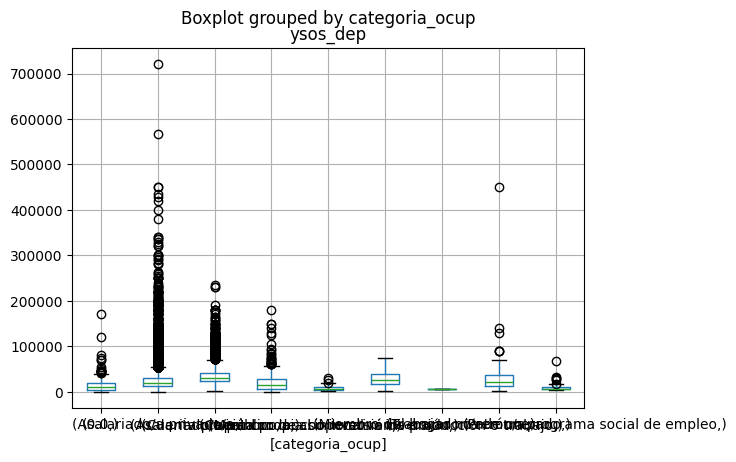

In [19]:
df_ysos.boxplot(column=['ysos_dep'], by=['categoria_ocup']);
print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count())
print(df_ysos.groupby(['categoria_ocup'])['ysos_dep'].count()/len(df_ysos))

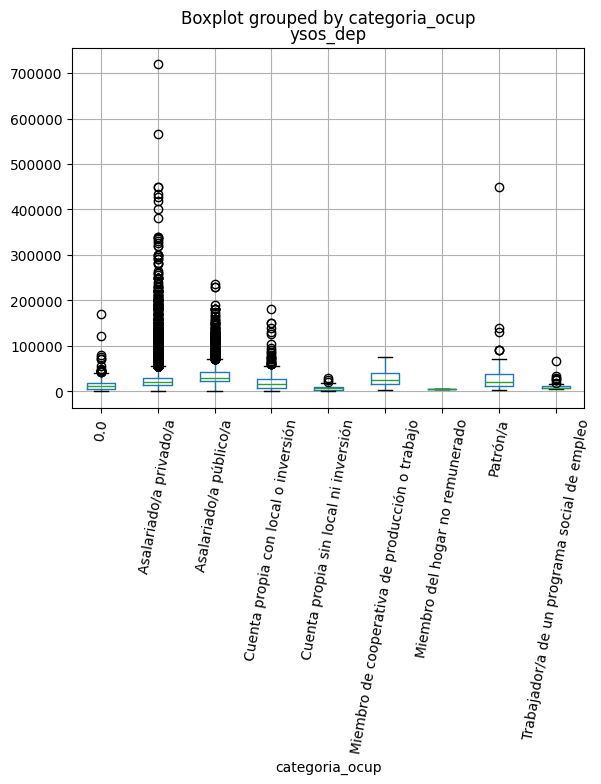

In [20]:
## — 1.  Pinta el boxplot
ax = df_ysos.boxplot(column='ysos_dep', by='categoria_ocup')
## — 2.  Rota etiquetas eje X
ax.tick_params(axis='x', rotation=80)
## — 3.  Imprimir
plt.show();

In [21]:
df_ysos = df_ysos.loc[(df_ysos['categoria_ocup'] == "Asalariado/a privado/a") | (df_ysos['categoria_ocup'] == "Asalariado/a público/a")]

In [22]:
df_ysos['categoria_ocup'].head()

,categoria_ocup
0,Asalariado/a privado/a
2,Asalariado/a público/a
5,Asalariado/a privado/a
7,Asalariado/a privado/a
8,Asalariado/a privado/a


## **02. Tarea 2.1**
Estudiar las principales características de la variable de respuesta: análisis gráfico de normalidad; opción por la transformación logarítmica. Investigar qué presentan las gráficas qqplot y qué conclusiones podemos extraer acerca de la normalidad de la variable

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Variable respuesta: Gráfico| Finalizado|
|b| Variable respuesta: QQPLot|Finalizado|
|c|Normalizo aplicando Logaritmo la variable de respuesta|Finalizado|
|d|Visualizo qqplot luego de Logartimización|Finalizado|
|e|Defino nuevo dataset con variable de respuesta normalizada| Finalizado|
|f|Comportamiento de la variable de respuesta vs variables predictoras| Finalizado|
|g|plotear distribución del dataset| Finalizado|









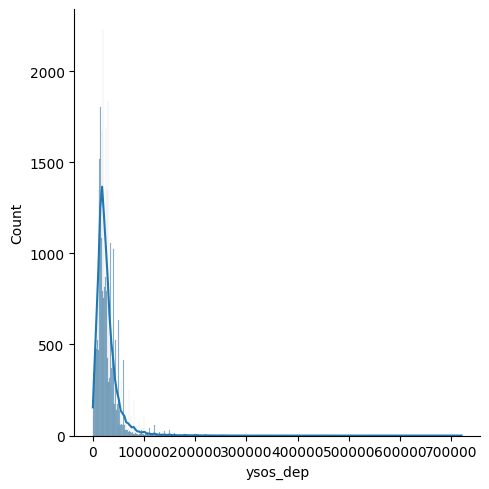

In [23]:
# a: Gráfico variable respuesta

sns.displot(df_ysos['ysos_dep'], kde = True)

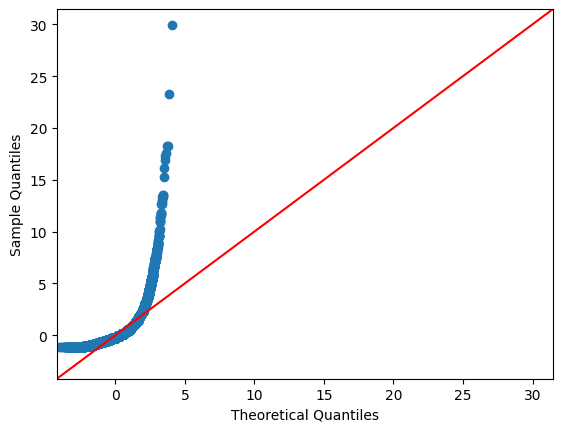

In [24]:
# b. Gráfico qqplot (¿Para que?)

sm.qqplot(np.array(df_ysos['ysos_dep']), line='45', fit=True);

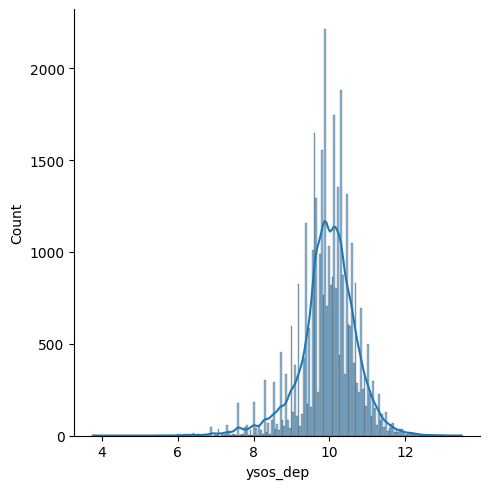

In [25]:
# C. Normalizo aplicando Logaritmo la variable de respuesta

sns.displot(np.log(df_ysos['ysos_dep']), kde = True)

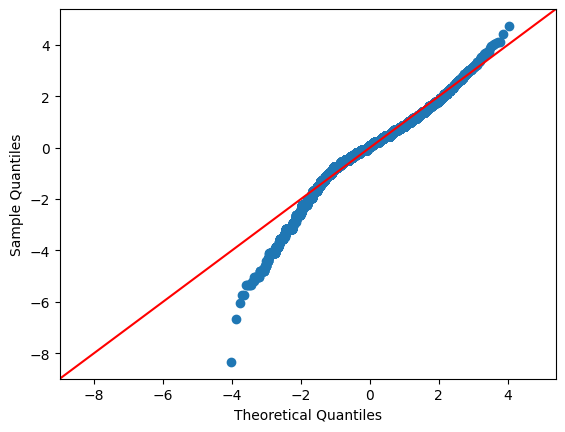

In [26]:
# d. Visualizo qqplot luego de Logartimización

sm.qqplot(np.array(np.log(df_ysos['ysos_dep'])), line='45', fit=True); #punto y coma evita duplicación del gráfico

In [27]:
# e. Defino nuevo dataset con variable de respuesta normalizada

df_ysos['l_ysos_dep'] = np.log(df_ysos['ysos_dep'])
df_l_ysos = df_ysos.drop(columns=['ysos_dep'])
df_l_ysos.head()

,edad,sexo,anios_educ,antiguedad,categoria_ocup,l_ysos_dep
0,70.0,Hombre,6.0,7.0,Asalariado/a privado/a,9.798127
2,52.0,Hombre,6.0,32.0,Asalariado/a público/a,10.778956
5,42.0,Mujer,16.0,0.0,Asalariado/a privado/a,10.404263
7,29.0,Mujer,8.0,1.0,Asalariado/a privado/a,7.783224
8,37.0,Hombre,6.0,4.0,Asalariado/a privado/a,10.043249


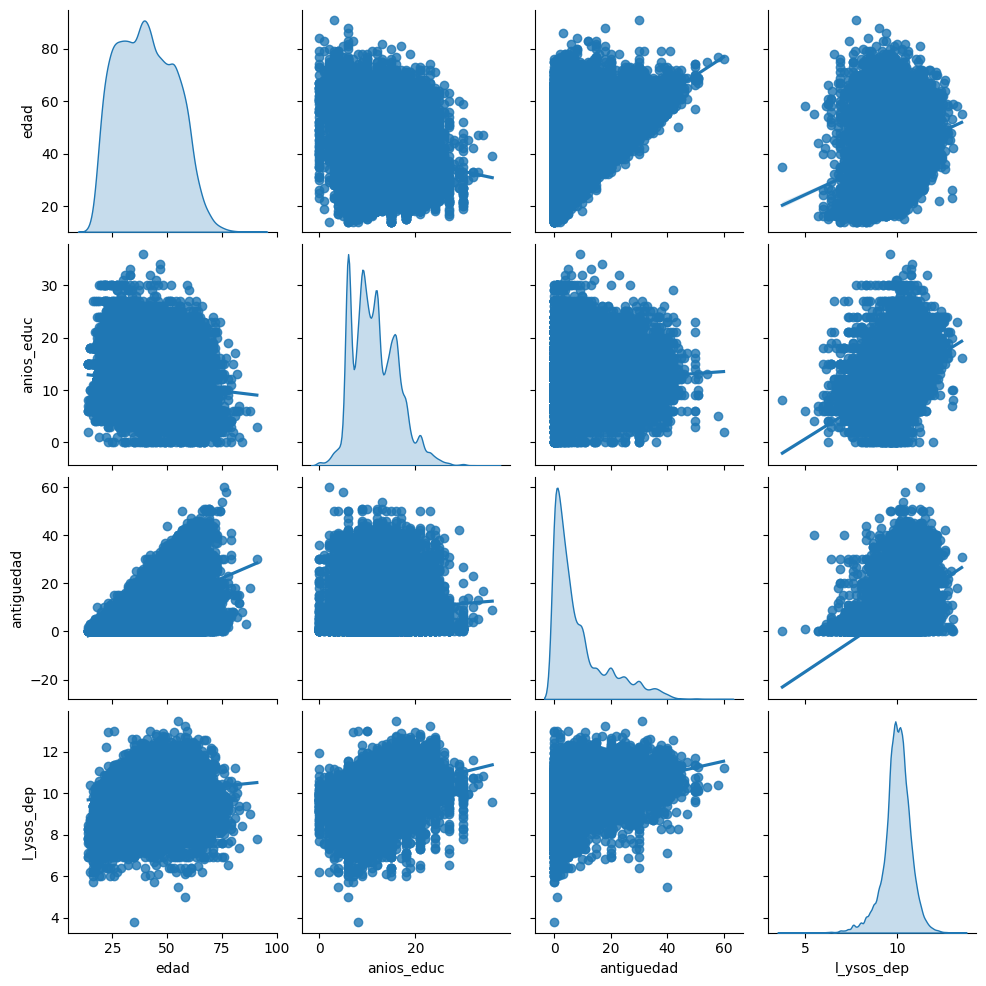

In [28]:
# f. Comportamiento de la variable de respuesta vs variables predictoras

sns.pairplot(df_l_ysos, kind="reg", diag_kind="kde")

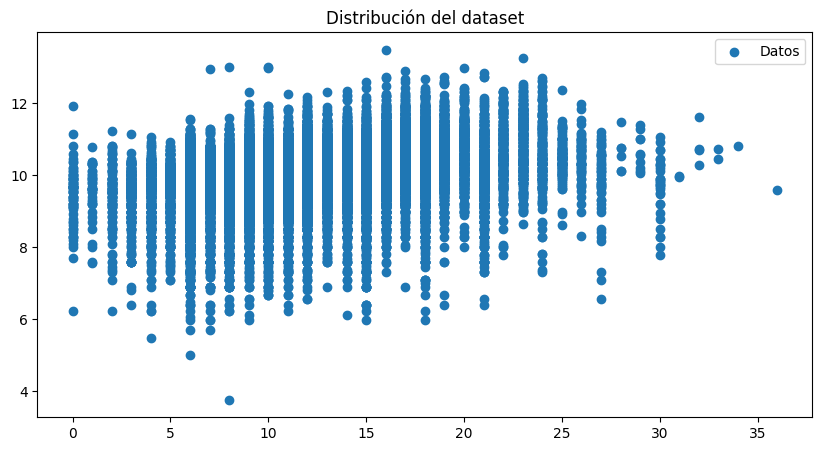

In [29]:
# g. plotear distribución del dataset

plt.figure(figsize=(10,5))
plt.scatter(df_l_ysos['anios_educ'], df_ysos['l_ysos_dep'], label='Datos')
plt.title('Distribución del dataset')
plt.legend()

<Axes: title={'center': 'l_ysos_dep'}, xlabel='[anios_educ]'>

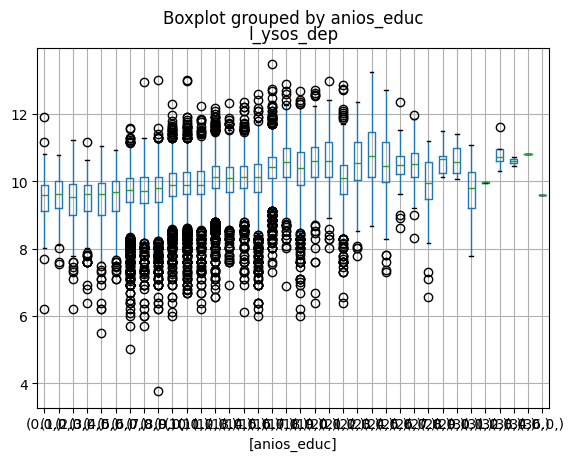

In [30]:
#

df_l_ysos.boxplot(column='l_ysos_dep', by=['anios_educ'])

<Axes: title={'center': 'l_ysos_dep'}, xlabel='[categoria_ocup]'>

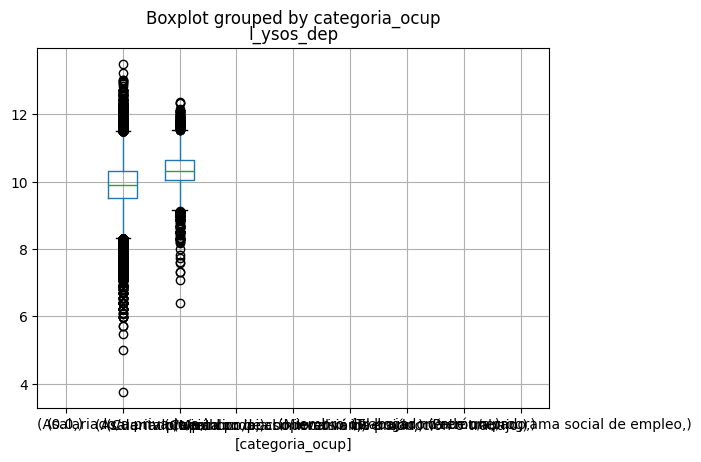

In [31]:
#

df_l_ysos.boxplot(column=['l_ysos_dep'], by=['categoria_ocup'])

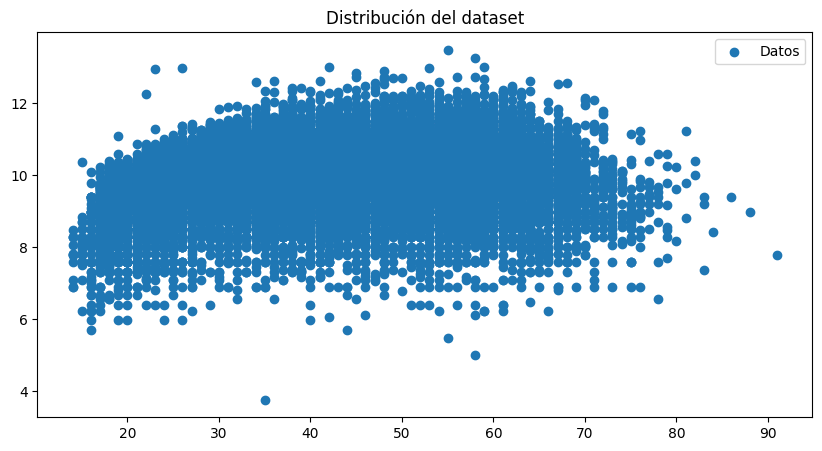

In [32]:
#

plt.figure(figsize=(10,5))
plt.scatter(df_l_ysos['edad'], df_l_ysos['l_ysos_dep'], label='Datos')
plt.title('Distribución del dataset')
plt.legend()

## **03. Tarea 2.2**
Completar el análisis exploratorio de datos (AED) de variables predictoras, en particular sobre la correlación entre variables predictoras (buscar métodos gráficos para ello) y sus consecuencias en la implementación de regresión

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| | |

In [ ]:
# Realizar Tarea 2

## **04. Tarea 2.3**
Investigar qué es y en qué condiciones conviene realizar la ESTANDARIZACIÓN de
variables numéricas en el contexto de regresión para la transformación de  variables predictoras numéricas

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Definir Variables númericas y Categoricas | No comenzado|
|b| Generar columna transformadora| No comenzado|
|c| Realizar transformación| No comenzado|


In [ ]:
# a. Definir Variables númericas y Categoricas

categorical_columns = ['sexo', 'categoria_ocup']
numerical_columns = ['edad', 'anios_educ', 'antiguedad']


In [ ]:

# b. Generar la columna transformadora

column_transform = make_column_transformer(
    (OneHotEncoder(drop='if_binary'), categorical_columns), # cuando son dos categorías, elimina una
    #(StandardScaler(), numerical_columns), # comentado mientras no se decida estandarizar
    remainder='passthrough', # deja el resto de las columnas sin transformar
    verbose_feature_names_out=False)

In [ ]:
# Realizar la transformación

df_l_ysos_transf = pd.DataFrame(
    column_transform.fit_transform(df_l_ysos),
    columns=column_transform.get_feature_names_out()
)

df_l_ysos_transf.head()

## **05. Tarea 2.4**
Realizar al menos tres derivaciones del modelo 2 (2.a, 2.b, 2.c) cada una con mayor grado en el polinomio. Analizar los resultados y conclusiones, considerando particularmente la evidencia acerca del problema del sobreajuste. Nota: puede ser seleccionada otra variable para realizar la regresión polinómica, con miras a un mejor desempeño

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Partición del dataset | No realizado |
|b| X_train| No realizado|
|c| X_test| No realizado|
_______________________
*Modelo 1*
|# | Tarea | Estado|
|---|---|---|
|Mod_1a| Defino x_train | No realizado |
|Mod_1b| Defino x_test| No realizado|
|Mod_1c|Entreno el modelo| No realizado|
|Mod_1d| Interpretación de los coeficientes| No realizado|
|Mod_1e| Coeficiente de determinación R2| No realizado|
|Mod_1f| Plot| No realizado|
|Mod_1g| Predicción| No realizado
|Mod_1h| Error medio cuadratico_train| No realizado|
|Mod_1i| Error medio cuadratico_test| No realizado|
|Mod_1j| Plot outputs| No realizado|
_________________________
*Modelo 2*
|# | Tarea | Estado|
|---|---|---|
|Mod_2a| Defino x_train y X_test| No realizado |
|Mod_2b| Entreno el modelo| No realizado|
|Mod_2c| Coeficientes de regresión| No realizado|
|Mod_2d| Coeficeintes de determinación (R2)| No realizado
|Mod_2e| Realizo predicción| No realizado|
|Mod_2f| Error cuadratico medio_train| No realizado|
|Mod_2g| Error cuadratico medio_test| No realizado|
____________________________
*Modelo 3*
|# | Tarea | Estado|
|---|---|---|
|Mod_3a|Completar |No realizado|
|Mod_3b|Completar |No realizado|
|Mod_3c|Completar |No realizado|
|Mod_3d|Completar |No realizado|

In [ ]:
# a: Partición del dataset

X_train, X_test, y_train, y_test = train_test_split(df_l_ysos_transf[['edad', 'sexo_Mujer', 'anios_educ', 'antiguedad', 'categoria_ocup_Asalariado/a público/a']], \
                                                    df_l_ysos_transf['l_ysos_dep'],
                                                    test_size=0.20,
                                                    random_state=1234)

In [ ]:
# b Defino X_train

X_train

In [ ]:
# c. Defino X_test
X_test

#Modelo 1.

Modelo lineal simple: una sola variable independiente. Utilizamos double bracket para mantener estructura de dataframe (sklearn sólo acepta objetos de 2D en train; un sólo paréntesis recto devuelve una Serie, dos paréntesis rectos devuelven un DataFrame).

In [ ]:
# Mod_1a: Defino X_train

type(X_train['anios_educ'])

In [ ]:
# Mod_1b: Defino X_train (No deberia decir X_test?)

type(X_train[['anios_educ']])

In [ ]:
# Mod_1c: Entreno el modelo

mod1_X_train = X_train[['anios_educ']]
mod1_X_test = X_test[['anios_educ']]

mod1 = reg.fit(mod1_X_train, y_train)

In [ ]:
# Mod_1d: regression coefficients

print('Coefficients: ', mod1.coef_)
print('Intercept: ', mod1.intercept_ )

print('Cuando solamente la variable de respuesta fue transformada mediante el logaritmo, el coeficiente beta se interpreta como una variación de ',
     np.around((np.exp(mod1.coef_)-1)*100, 2), '% de la variable de respuesta por cada unidad de variación de la variable independiente')

In [ ]:
# Mod_1e: Coefficient of determination (R2)

mod1.score(mod1_X_test, y_test)

In [ ]:
# Mod_1f: Plot

plt.scatter(mod1.predict(mod1_X_test), mod1.predict(mod1_X_test) - y_test,
            color = "blue", s = 10, label = 'Test data')

In [ ]:
# Mod_1g: Predicción Modelo 1

# predicción en train
mod1_y_train_pred = mod1.predict(mod1_X_train)

# predicción en test
mod1_y_test_pred = mod1.predict(mod1_X_test)

In [ ]:
# Mod_1h: Error medio cuadratico_train

mod1_mse_train = mean_squared_error(y_train, mod1_y_train_pred)
mod1_mse_train

In [ ]:
# Mod_1i: Error medio cuadratico_test

mod1_mse_test = mean_squared_error(y_test, mod1_y_test_pred)
mod1_mse_test

In [ ]:
# Mod_1j: Plot outputs
plt.scatter(mod1_X_test, y_test, color="black")
plt.plot(mod1_X_test, mod1_y_test_pred, color="blue", linewidth=3)

#Modelo 2.

Regresión polinómica (generalización del modelo lineal simple). Utilizamos una función ad-hoc para crear el polinomio, descartando el intercepto (columna de valor 1), ya que lo trae por defecto reg.fit.

In [ ]:
# Mod_2a: Defino X_traing y X_Test

mod2_X_train = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_train[['anios_educ']])
mod2_X_test = PolynomialFeatures(degree=2, include_bias=False).fit_transform(X_test[['anios_educ']])



In [ ]:
# Mod_2b: Entreno el modelo

mod2 = reg.fit(mod2_X_train, y_train)

In [ ]:
# Mod_2c: regression coefficients

print('Coefficients: ', mod2.coef_)
print('Intercept: ', mod2.intercept_ )

In [ ]:
# Mod_2d: Coefficient of determination (R2)
mod2.score(mod2_X_test, y_test)

In [ ]:
# Mod_2e: Realizo Predicción

# predicción en train
mod2_y_train_pred = mod2.predict(mod2_X_train)

# predicción en test
mod2_y_test_pred = mod2.predict(mod2_X_test)

In [ ]:
# Mod_2f: Error cuadratico medio_ train

mod2_mse_train = mean_squared_error(y_train, mod2_y_train_pred)
mod2_mse_train

In [ ]:
# Mod_2g: Error cuadratico medio_test

mod2_mse_test = mean_squared_error(y_test, mod2_y_test_pred)
mod2_mse_test

#Modelo 3.

Regresión polinómica (generalización del modelo lineal simple). Utilizamos una función ad-hoc para crear el polinomio, descartando el intercepto (columna de valor 1), ya que lo trae por defecto reg.fit.

In [ ]:
#Mod_3a:

#define response variable
mod3_y_train = y_train
mod3_y_test = y_test

#define predictor variables
mod3_X_train = X_train
mod3_X_test = X_test

#add constant to predictor variables
mod3_X_train = sm.add_constant(mod3_X_train)
mod3_X_test = sm.add_constant(mod3_X_test)

#fit linear regression model
mod3 = sm.OLS(mod3_y_train, mod3_X_train).fit()

#view model summary
print(mod3.summary())

# modify figure size
fig = plt.figure(figsize=(14, 8))

# creating regression plots
fig = sm.graphics.plot_regress_exog(mod3,
                                    'anios_educ',
                                    fig=fig)

In [ ]:
#Mod_3b:

# predicción en train
mod3_y_train_pred = mod3.predict(mod3_X_train)

# predicción en test
mod3_y_test_pred = mod3.predict(mod3_X_test)

In [ ]:
#Mod_3c:

mod3_mse_train = mean_squared_error(mod3_y_train, mod3_y_train_pred)
mod3_mse_train

In [ ]:
#Mod_3d:

mod3_mse_test = mean_squared_error(mod3_y_test, mod3_y_test_pred)
mod3_mse_test

## **06. Tarea 2.5**
Incorporar más variables. Analizar los resultados y conclusiones, considerando
particularmente la evidencia acerca del problema del sobreajuste. Conviene hacerlo desde el principio (preparación de los datos)

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| | |

In [ ]:
# Realizar

# Parentesis 1: Pipeline

¿Qué es el pipeline en machine learning? Los pipelines de datos se caracterizan por definir el conjunto de pasos o fases y las tecnologías involucradas en un proceso de movimiento o procesamiento de datos.

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Make Pipeline | No realizado|
|b| Crear Pipe, entrenar, predecir| No realizado|
|c|Print Error train y test| No realizado|

In [ ]:
#a.

pipeline = make_pipeline(StandardScaler(), LinearRegression())

In [ ]:
#b.

# creating a pipe using the make_pipeline method
pipeline = make_pipeline(StandardScaler(),
                         LinearRegression())

#fitting data into the model
pipeline.fit(X_train, y_train)

# predicting values
y_test_pred = pipeline.predict(X_test)
y_train_pred = pipeline.predict(X_train)

In [ ]:
#c.

print('Model Error Train: %.4f' % mean_squared_error(y_train, y_train_pred))
print('Model Error Test: %.4f' % mean_squared_error(y_test, y_test_pred))

# Parentesis 2: Validación cruzada

- Información de la función **cross_val_score**: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

- Información de scoring: https://scikit-learn.org/stable/modules/model_evaluation.html

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| k_folds| No realizado|
|b| CV_results| No realizado|
|c| Promedio| No realizado|
|d| Completar| No realizado|
|e| Error medio cuadratico| No realizado|
|f| Imprimir resultados | NO realizado|
|g| | No realizado|







In [ ]:
# a. K_folds

k_folds = 10

In [ ]:
# b. CV_results

cv_results = cross_val_score(pipeline, X = X_train, y = y_train, cv = k_folds, scoring='neg_mean_squared_error')
print('CV Error for a %s folds: \n%s' %(k_folds, -1*cv_results))

In [ ]:
# c. Calcula el promedio

average_cv = np.mean(cv_results)
print('Model Error CV: %.3f +/- %.3f' % (-1*average_cv,np.std(cv_results)))

In [ ]:
# d.

# Crear una lista con los números de fold
folds = np.arange(1, len(cv_results) + 1)

# Crear el gráfico
plt.figure(figsize=(8, 6))
plt.plot(folds, cv_results, marker='o', linestyle='-')
plt.title('Resultados de Validación Cruzada por Fold')
plt.xlabel('Fold')
plt.ylabel('Resultado de Validación Cruzada')
plt.grid(True)

# Agregar el valor de cada punto
for i, result in enumerate(cv_results):
    plt.text(folds[i], result, f'{result:.2f}', ha='center', va='bottom')

# Agregar el promedio
plt.axhline(y=average_cv, color='r', linestyle='--', label=f'Promedio: {average_cv:.2f}')
plt.legend()

plt.show()

In [ ]:
# e. Error medio cuadratico

error_train = mean_squared_error(y_train, y_train_pred)
error_test = mean_squared_error(y_test, y_test_pred)
error_cv = -1*np.mean(cv_results)

In [ ]:
# f. Imprimir resultados

print('Model Error Train: %.4f' % error_train)
print('Model Error CV   : %.4f' % error_cv)
print('Model Error Test : %.4f' % error_test)

In [ ]:
# g.

# Definir el orden de las etiquetas y los errores correspondientes
labels = ['Entrenamiento', 'CV', 'Test']
errors = [error_train, error_cv, error_test]

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
plt.bar(labels, errors, color=['skyblue', 'lightgreen', 'salmon'])  # Colores para las barras
plt.title('Comparación de Errores')
plt.ylabel('Error')
plt.ylim(0, max(errors) * 1.2)  # Ajustar el rango del eje y para dejar espacio para las etiquetas
plt.grid(axis='y')

# Mostrar los valores en las barras
for i, error in enumerate(errors):
    plt.text(i, error, f'{error:.4f}', ha='center', va='bottom')

plt.show()

## **07. Tarea 2.6**
Analizar los resultados de utilizar validación cruzada, ¿qué conclusiones obtiene?

*Resumen*
|# | Tarea | Estado|
|---|---|---|
|a| Completar| No realizado|